<a href="https://colab.research.google.com/github/dmamur/elembert/blob/noPosEmbeddings/notebooks/length_rcut/elembert_classification_kfolds_nucleation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This notebook present example of classification of Nucleation dataset from CegaNN model: https://github.com/sbanik2/CEGANN/tree/main/pretrained/Nucleation

The training set contains 400 bulk structures (200 solid-state with 544 atoms and 200 amorphous with 650 atoms), while the test set features a much larger structure (10,969 atoms) enclosed by a vacuum along one dimension.
For scalability and cutoff sensitivity analysis, we trained the V1 model on this dataset. The 400-structure set was used for k-fold splitting, while the target set served for cross-validation.

In [ ]:
import pickle,random
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import Embedding,Dense,Dropout,Input,Lambda
from tensorflow.keras.models import Model
import tensorflow.keras.backend as K
import re, glob,os,sys
from collections import defaultdict
from tensorflow.keras.utils import plot_model
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import roc_auc_score

def bert_module(query, key, value, i, config):
    # Multi headed self-attention
    attention_output = layers.MultiHeadAttention(
        num_heads=config.NUM_HEAD,
        key_dim=config.EMBED_DIM // config.NUM_HEAD,
        name="encoder_{}_multiheadattention".format(i),
        kernel_initializer=tf.keras.initializers.GlorotUniform(seed=config.seed)
    )(query, key, value)
    attention_output = layers.Dropout(0.1, name="encoder_{}_att_dropout".format(i))(
        attention_output
    )
    attention_output = layers.LayerNormalization(
        epsilon=1e-6, name="encoder_{}_att_layernormalization".format(i)
    )(query + attention_output)

    # Feed-forward layer
    ffn = tf.keras.Sequential(
        [
            layers.Dense(config.FF_DIM, activation="relu",kernel_initializer=tf.keras.initializers.GlorotUniform(seed=config.seed)),
            layers.Dense(config.EMBED_DIM,kernel_initializer=tf.keras.initializers.GlorotUniform(seed=config.seed)),
        ],
        name="encoder_{}_ffn".format(i),
    )
    ffn_output = ffn(attention_output)
    ffn_output = layers.Dropout(0.1, name="encoder_{}_ffn_dropout".format(i))(
        ffn_output
    )
    sequence_output = layers.LayerNormalization(
        epsilon=1e-6, name="encoder_{}_ffn_layernormalization".format(i)
    )(attention_output + ffn_output)
    return sequence_output


def get_pos_encoding_matrix(max_len, d_emb):
    pos_enc = np.array(
        [
            [pos / np.power(10000, 2 * (j // 2) / d_emb) for j in range(d_emb)]
            if pos != 0
            else np.zeros(d_emb)
            for pos in range(max_len)
        ]
    )
    pos_enc[1:, 0::2] = np.sin(pos_enc[1:, 0::2])  # dim 2i
    pos_enc[1:, 1::2] = np.cos(pos_enc[1:, 1::2])  # dim 2i+1
    return pos_enc

def create_elembert_model(inputs,config):
    word_embeddings = layers.Embedding(config.VOCAB_SIZE, config.EMBED_DIM, mask_zero=True,name="element_embdgs",
                                       embeddings_initializer=tf.keras.initializers.GlorotUniform(seed=config.seed))(inputs)
    encoder_output = word_embeddings
    for i in range(config.NUM_LAYERS):
        encoder_output = bert_module(encoder_output, encoder_output, encoder_output, i, config)
    mlm_model = Model(inputs, encoder_output, name="masked_bert_model")

    return mlm_model


In [ ]:
!git clone https://github.com/dmamur/elementsem.git

fatal: destination path 'elementsem' already exists and is not an empty directory.


In [ ]:
class Config:
    MAX_LEN = 11000
    BATCH_SIZE = 1
    LR = 0.001
    VOCAB_SIZE = 128
    EMBED_DIM = 32
    NUM_HEAD = 2 # used in bert model
    FF_DIM = 32 # used in bert model
    NUM_LAYERS = 2
    MNAME = 'elembert_'
    DSPATH="/content/elementsem/data/"
    PREPATH="/content/elementsem/models/pretrained/"
    PATH="/content/elementsem/models/"
config = Config()
seed=12345
tf.random.set_seed(seed)
np.random.seed(seed)

In [ ]:
ds = 'nucleation_kmRcut_Si'

config.MVER = 'KmRcut5' #By varying this parameter, the cutoff effect can be investigated, with 5,10 and 15 Å possible options: KmRcut5, KmRcut10, KmRcut15

mname=config.PATH+config.MNAME+ds+'_%s_E_%s_H_%s_L_%s' % (config.MVER,config.EMBED_DIM,config.NUM_HEAD,config.NUM_LAYERS)

# Load vocabulary and types

In [ ]:
df = pd.read_csv(config.DSPATH+ds+'_ds.zip')

types = df['types'+config.MVER].apply(eval).apply(list)
labels_  = to_categorical(np.asarray(df['labels']))
uniquelbls=len(np.unique(np.asarray(df['labels'])))


with open(config.PREPATH+'/el2idV1.pkl', 'rb') as f:
    db = pickle.load(f)

element2id = db['el2id']
el2id = db['el2id']
config.VOCAB_SIZE = len(element2id)
print('vocabSize: ', config.VOCAB_SIZE)


vocabSize:  565


# Convert types to integers

In [ ]:
#[random.shuffle(types[i]) for i in range(len(types))]
types0=[['[CLS]']+i+['[SEP]'] for i in types]
typesNumerical=[]
for i in types0:
    typesNumerical.append([element2id[j] for j in i])

x3_ = tf.keras.preprocessing.sequence.pad_sequences(typesNumerical,dtype='int32',padding= 'post',truncating='post',maxlen=config.MAX_LEN)
npoints=401
testlabels=labels_[npoints:]
testx3=x3_[npoints:]
labels = labels_[:npoints]
x3 = x3_[:npoints]
#z = load_model(config.PREPATH+'/elembert_%s_E_%s_H_%s_L_%s.h5' % (config.MVER,config.EMBED_DIM,config.NUM_HEAD,config.NUM_LAYERS),compile=False)
#z.trainable = True

inputC = Input((config.MAX_LEN,), dtype=tf.int32,name='types')


In [ ]:
def scheduler(epoch):
    initial_lrate = config.LR
    drop = 0.92
    epochs_drop = 10
    lr = initial_lrate * np.power(drop, np.floor((1+epoch)/epochs_drop))
    if lr<0.0001:
        lr = 0.0001
    return lr


epochs=config.BATCH_SIZE

print('dataLen: ',x3.shape,labels.shape)

dataLen:  (401, 11000) (401, 2)


In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report

# Assuming you have loaded your data into x3 and labels variables

# Define the number of folds
num_folds = 2

# Initialize Stratified K-Fold Cross-Validator
kfold = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)

# Initialize lists to store results
all_histories = []
all_reports = []
randseed = np.asarray([38005, 26930, 57873, 37766, 62593])
# Iterate over folds
roc_auc,roc_auc_test=[],[]
for fold, (train_idx, val_idx) in enumerate(kfold.split(x3, np.argmax(labels, axis=1))):
    print(f"\nTraining on Fold {fold + 1}...")
    config.seed = int(randseed[fold])
    z = create_elembert_model(inputC,config)
    e = Lambda(lambda x: x[:,0],name='clsTokenEmb')(z.output)
    f = Dense(uniquelbls, activation="softmax",name='out_tox',kernel_initializer=tf.keras.initializers.GlorotUniform(config.seed))(e)
    # Create and compile the model (assuming create_elembert_model function is available)
    model = Model(inputs=z.input, outputs=f)

    optimizer = tf.keras.optimizers.Adam(learning_rate=config.LR)
    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=[tf.keras.metrics.AUC()])

    # Extract training and validation sets
    x_train, x_val = x3[train_idx], x3[val_idx]
    y_train, y_val = labels[train_idx], labels[val_idx]

    # Train the model
    history = model.fit(
        x=x_train,
        y=y_train,
        validation_data=(x_val, y_val),
        epochs=epochs,
        batch_size=config.BATCH_SIZE,
        verbose=1,
        callbacks = tf.keras.callbacks.LearningRateScheduler(scheduler)
    )

    # Evaluate the model on the validation set
    val_predictions = model.predict(x_val, batch_size=config.BATCH_SIZE)
    val_report = classification_report(np.argmax(y_val, axis=1), np.argmax(val_predictions, axis=1), output_dict=True)

    test_predictions = model.predict(testx3, batch_size=config.BATCH_SIZE)

    # Append results to lists
    all_histories.append(history)
    all_reports.append(val_report)
    roc_auc.append(roc_auc_score(np.argmax(y_val, axis=1), np.argmax(val_predictions, axis=1)))
    #roc_auc_test.append(roc_auc_score(testlabels, test_predictions))
    roc_auc_test.append(roc_auc_score(np.argmax(testlabels, axis=1), np.argmax(test_predictions, axis=1)))
    print(fold, roc_auc[-1],roc_auc_test[-1])

# Print the average classification report across folds
#avg_report = pd.DataFrame(all_reports).mean().to_dict()
#print("\nAverage Classification Report Across Folds:")
#print(avg_report)



Training on Fold 1...
200/200 ━━━━━━━━━━━━━━━━━━━━ 67s 249ms/step - auc: 0.8551 - loss: 0.4782 - val_auc: 1.0000 - val_loss: 0.0012 - learning_rate: 0.0010
201/201 ━━━━━━━━━━━━━━━━━━━━ 13s 60ms/step
101/101 ━━━━━━━━━━━━━━━━━━━━ 6s 58ms/step
0 1.0 0.5

Training on Fold 2...
201/201 ━━━━━━━━━━━━━━━━━━━━ 55s 220ms/step - auc_1: 0.8004 - loss: 0.5178 - val_auc_1: 1.0000 - val_loss: 7.2543e-04 - learning_rate: 0.0010
200/200 ━━━━━━━━━━━━━━━━━━━━ 12s 58ms/step
101/101 ━━━━━━━━━━━━━━━━━━━━ 6s 62ms/step
1 1.0 0.5


# Save results

In [ ]:
extractorEmb = Model(inputs=model.inputs,outputs=model.get_layer(name="clsTokenEmb").output)

preds = model.predict(x3_,batch_size = config.BATCH_SIZE)

dbresults={}
dbresults['pred_emb'] = extractorEmb.predict(x3_,batch_size = config.BATCH_SIZE)
dbresults['pred_cls'] = preds
dbresults['y_cls'] = labels_
dbresults['y_clsTarget'] = testlabels
dbresults['ids'] = df['ids']
dbresults['types'] = types
dbresults['trainidx'] = train_idx
dbresults['testidx'] = val_idx
dbresults['validx'] = val_idx

with open(mname+'_results.pkl', 'wb') as f:
    pickle.dump(dbresults, f)

502/502 ━━━━━━━━━━━━━━━━━━━━ 29s 58ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['types']
Received: inputs=Tensor(shape=(1, 11000))
  warnings.warn(msg)


502/502 ━━━━━━━━━━━━━━━━━━━━ 30s 58ms/step


# Postprocessing

In [ ]:
from matplotlib import cm
from sklearn.manifold import TSNE
from sklearn import metrics
import seaborn as sns
from sklearn.decomposition import PCA
tsne = TSNE(n_components=2, verbose=0, random_state=123)
pca = PCA(n_components=2)
z = tsne.fit_transform(dbresults['pred_emb'])
#z = pca.fit(dbresults['pred_emb'])
#z = pca.transform(dbresults['pred_emb'])

In [ ]:
dfr = pd.DataFrame()
dfr["y"] = np.asarray(dbresults['y_cls'].argmax(axis=-1)).astype('bool')
#dfr['y']=labels_.argmax(axis=-1)
dfr["yp"] = np.asarray(dbresults['pred_cls'].argmax(axis=-1)).astype('bool')
#dfr["yp"] = np.hstack((np.asarray(dbresults['pred_cls'].argmax(axis=-1)).astype('bool'),test_predictions.argmax(-1)))
dfr["tSNE1"] = z[:,0]
dfr["tSNE2"] = z[:,1]

/content/elementsem/models/elembert_nucleation_kmRcut_Si_KmRcut5_E_32_H_2_L_2 AUC: 1.0


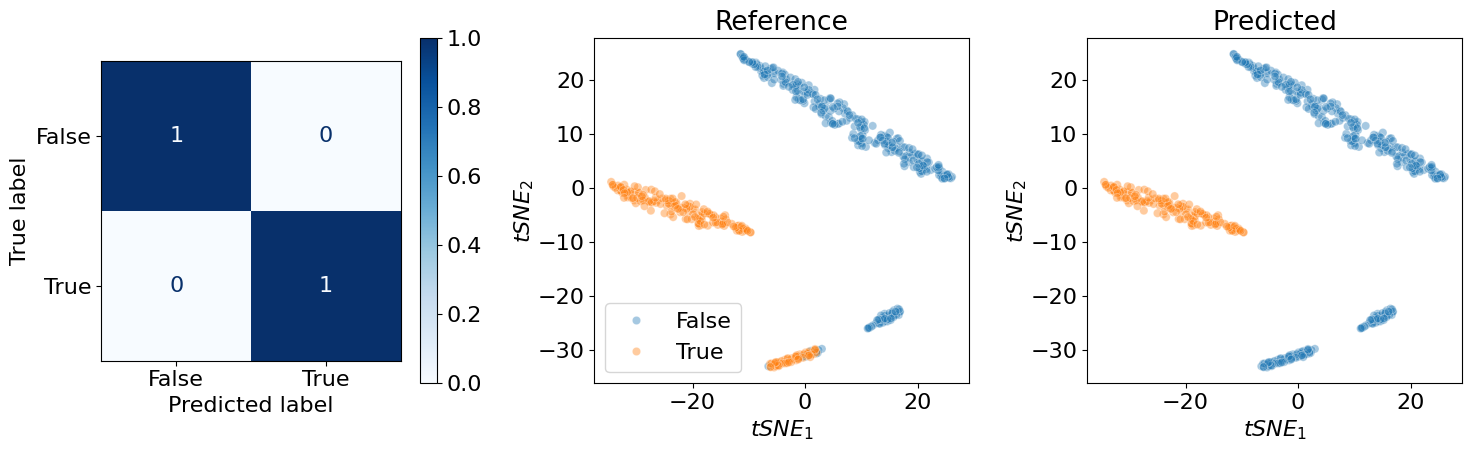

In [ ]:
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 16})
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))
y_pclasses = dbresults['pred_cls'][dbresults['testidx']].argmax(axis=-1).tolist()
y_classes = dbresults['y_cls'][dbresults['testidx']].argmax(axis=-1)
m = tf.keras.metrics.AUC()
m.update_state(dbresults['y_cls'][dbresults['testidx']], dbresults['pred_cls'][dbresults['testidx']])
print(mname,'AUC:',m.result().numpy())
confusion_matrix = metrics.confusion_matrix(y_classes, y_pclasses)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = np.round(confusion_matrix/ confusion_matrix.sum(axis=1)[:, np.newaxis]*100)/100,
                                            display_labels=['False','True'])
cm_display.plot(ax=axes[0],cmap=plt.cm.Blues)

#dfr=dfr.sort_values(by=['y'])
sns.scatterplot(ax=axes[1],x="tSNE1", y="tSNE2", hue=dfr.y.tolist(),data=dfr,alpha=0.4)#.set(title=title+" data T-SNE projection")
axes[1].set_xlabel('$tSNE_1$')
axes[1].set_ylabel('$tSNE_2$',labelpad=1)
axes[1].set_title('Reference')
#dfr=dfr.sort_values(by=['yp'])
sns.scatterplot(ax=axes[2],x="tSNE1", y="tSNE2", hue=dfr.yp.tolist(),data=dfr,alpha=0.4)#.set(title=title+" data T-SNE projection")
axes[2].set_title('Predicted')
axes[2].set_xlabel('$tSNE_1$')
axes[2].set_ylabel('$tSNE_2$',labelpad=1)
axes[2].legend('',frameon=False)
fig.tight_layout()
plt.savefig(mname+'_tsne.png',format='png',dpi=800,bbox_inches = "tight")
plt.show()

The model achieves an ROC-AUC score of 1.0 on the training set but only 0.5 on the test set. The confusion matrix and feature space distribution illustrate this discrepancy. As seen in the feature space, an additional cluster emerges in the test set (points between 20 and 40 on the x-axis), which is distant from the training clusters (ranging from -40 to 10 on the x-axis). The classification layer in the training dataset incorrectly assigns this new cluster to the "False" category. A detailed analysis reveals that this cluster is separable in feature space, but the predicted labels remain inaccurate. In such cases, fine-tuning can be applied to refine predictions.
To address this issue, we employed a simple and computationally efficient Gaussian Process Classification (GPC) model using features extracted from our elEmBERT-V1 model. Fine-tuning with a 2-fold cross-validation improved the ROC-AUC to 0.95 on the validation set.

## GPC

In [ ]:
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
X, y = dbresults['pred_emb'][dbresults['trainidx']],dbresults['y_cls'][dbresults['trainidx']].argmax(axis=-1)
X_val, Y_val = dbresults['pred_emb'][dbresults['testidx']],dbresults['y_cls'][dbresults['testidx']].argmax(axis=-1)
X_test, y_test = dbresults['pred_emb'][npoints:],dbresults['y_cls'][npoints:].argmax(axis=-1)
kernel = 1.0 * RBF(1.0)
gpc = GaussianProcessClassifier(kernel=kernel,
        random_state=0).fit(X, y)
gpc.score(X_val, Y_val)
print('GPC score: ',gpc.score(X_test, y_test))

GPC score:  0.504950495049505


In [ ]:
# Initialize lists to store results
all_histories = []
all_reports = []
roc_auc = []

# Iterate over folds
for fold, (train_idx, val_idx) in enumerate(kfold.split(X_test, y_test)):
    print(f"\nTraining on Fold {fold + 1}...")
    x_train, x_val = X_test[train_idx], X_test[val_idx]
    y_train, y_val = y_test[train_idx], y_test[val_idx]
    gpc = GaussianProcessClassifier(kernel=kernel,random_state=0).fit(x_train, y_train)
    print(gpc.score(x_val, y_val))
    test_predictions_gpc = gpc.predict_proba(X_test)


Training on Fold 1...
0.9411764705882353

Training on Fold 2...
0.94


In [ ]:
print(gpc.score(X, y))
print(gpc.score(X_val, Y_val))
print(gpc.score(X_test, y_test))

0.9800995024875622
0.975
0.9504950495049505


In [ ]:
dfr['gpc_cls']=gpc.predict(dbresults['pred_emb'])

/content/elementsem/models/elembert_nucleation_kmRcut_Si_KmRcut5_E_32_H_2_L_2 AUC: 0.98059994


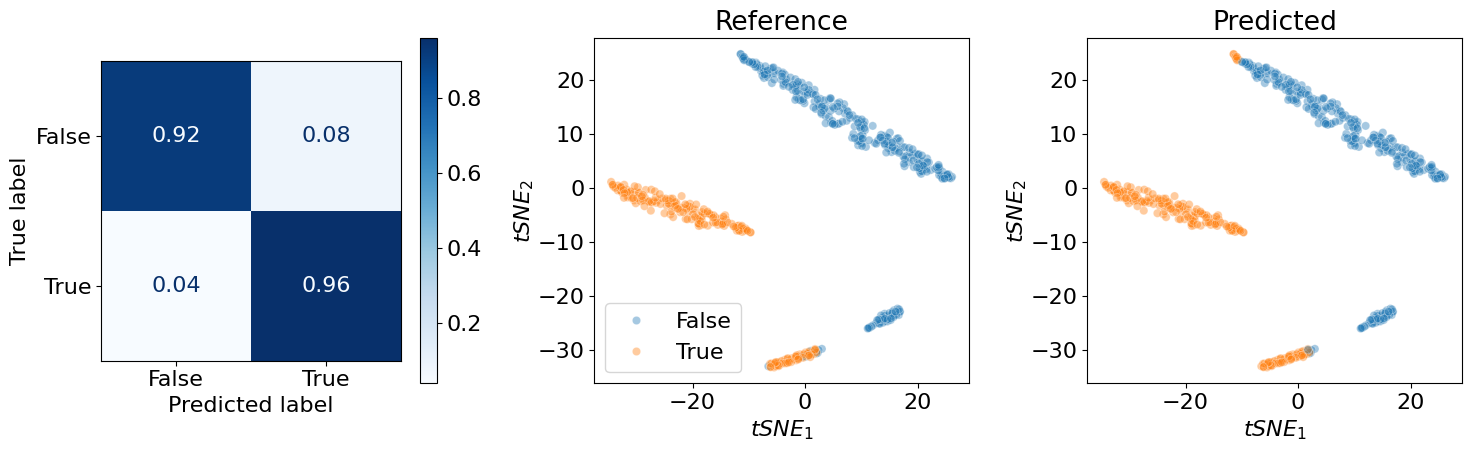

In [ ]:
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 16})
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))
y_pclasses = gpc.predict(x_val)
y_classes = y_val
m = tf.keras.metrics.AUC()
m.update_state(dbresults['y_clsTarget'][val_idx], gpc.predict_proba(x_val))
print(mname,'AUC:',m.result().numpy())
confusion_matrix = metrics.confusion_matrix(y_classes, y_pclasses)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = np.round(confusion_matrix/ confusion_matrix.sum(axis=1)[:, np.newaxis]*100)/100,
                                            display_labels=['False','True'])
cm_display.plot(ax=axes[0],cmap=plt.cm.Blues)

#dfr=dfr.sort_values(by=['y'])
sns.scatterplot(ax=axes[1],x="tSNE1", y="tSNE2", hue=dfr.y.tolist(),data=dfr,alpha=0.4)#.set(title=title+" data T-SNE projection")
axes[1].set_xlabel('$tSNE_1$')
axes[1].set_ylabel('$tSNE_2$',labelpad=1)
axes[1].set_title('Reference')
#dfr=dfr.sort_values(by=['yp'])
sns.scatterplot(ax=axes[2],x="tSNE1", y="tSNE2", hue=dfr.gpc_cls.tolist(),data=dfr,alpha=0.4)#.set(title=title+" data T-SNE projection")
axes[2].set_title('Predicted')
axes[2].set_xlabel('$tSNE_1$')
axes[2].set_ylabel('$tSNE_2$',labelpad=1)
axes[2].legend('',frameon=False)
fig.tight_layout()
plt.savefig(mname+'_gpc_tsne.png',format='png',dpi=800,bbox_inches = "tight")
plt.show()

/content/elementsem/models/elembert_nucleation_kmRcut_Si_KmRcut5_E_32_H_2_L_2 AUC: 0.98059994


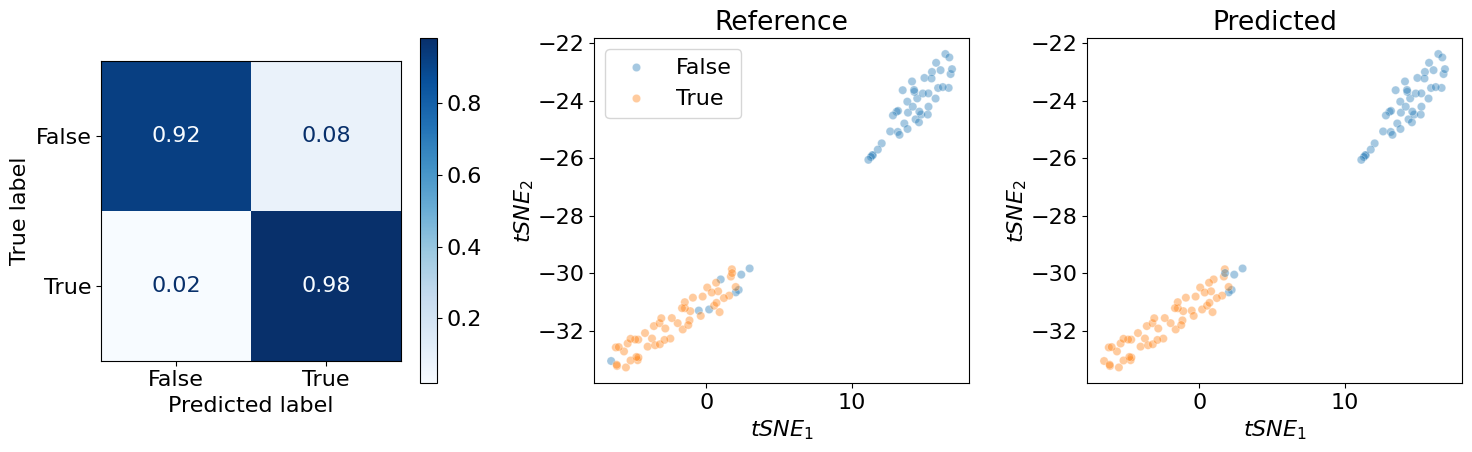

In [ ]:
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 16})
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))

df_last_101 = dfr.iloc[401:]
y_pclasses = df_last_101.gpc_cls.tolist()
y_classes = df_last_101.y.tolist()
m = tf.keras.metrics.AUC()
m.update_state(dbresults['y_cls'][npoints:][val_idx], gpc.predict_proba(x_val))
print(mname,'AUC:',m.result().numpy())
confusion_matrix = metrics.confusion_matrix(y_classes, y_pclasses)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = np.round(confusion_matrix/ confusion_matrix.sum(axis=1)[:, np.newaxis]*100)/100,
                                            display_labels=['False','True'])
cm_display.plot(ax=axes[0],cmap=plt.cm.Blues)

#dfr=dfr.sort_values(by=['y'])
sns.scatterplot(ax=axes[1],x="tSNE1", y="tSNE2", hue=df_last_101.y.tolist(),data=df_last_101,alpha=0.4)#.set(title=title+" data T-SNE projection")
axes[1].set_xlabel('$tSNE_1$')
axes[1].set_ylabel('$tSNE_2$',labelpad=1)
axes[1].set_title('Reference')
#dfr=dfr.sort_values(by=['yp'])
sns.scatterplot(ax=axes[2],x="tSNE1", y="tSNE2", hue=df_last_101.gpc_cls.tolist(),data=df_last_101,alpha=0.4)#.set(title=title+" data T-SNE projection")
axes[2].set_title('Predicted')
axes[2].set_xlabel('$tSNE_1$')
axes[2].set_ylabel('$tSNE_2$',labelpad=1)
axes[2].legend('',frameon=False)
fig.tight_layout()
plt.savefig(mname+'_test_tsne.png',format='png',dpi=800,bbox_inches = "tight")
plt.show()

In [ ]:
dfr.to_csv(mname+'_dfr.csv')